In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.analysis.calculate_metastability_optimize_K import find_optimal_K, plot_K_optimization


%load_ext autoreload
%autoreload 2 

In [ ]:
# wei: 
# data_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_orig.npy"

# bin and thres and sampled to 100 nodes total: 
data_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy"

A = np.load(data_path)[0]

Optimizing K: 100%|██████████| 50/50 [00:35<00:00,  1.43it/s]



Optimization Results:
Metric optimized: global
Optimal K: 0.0164
Value at optimal K: 0.0004
K range tested: [0.0001, 0.1000]
Number of K values: 50



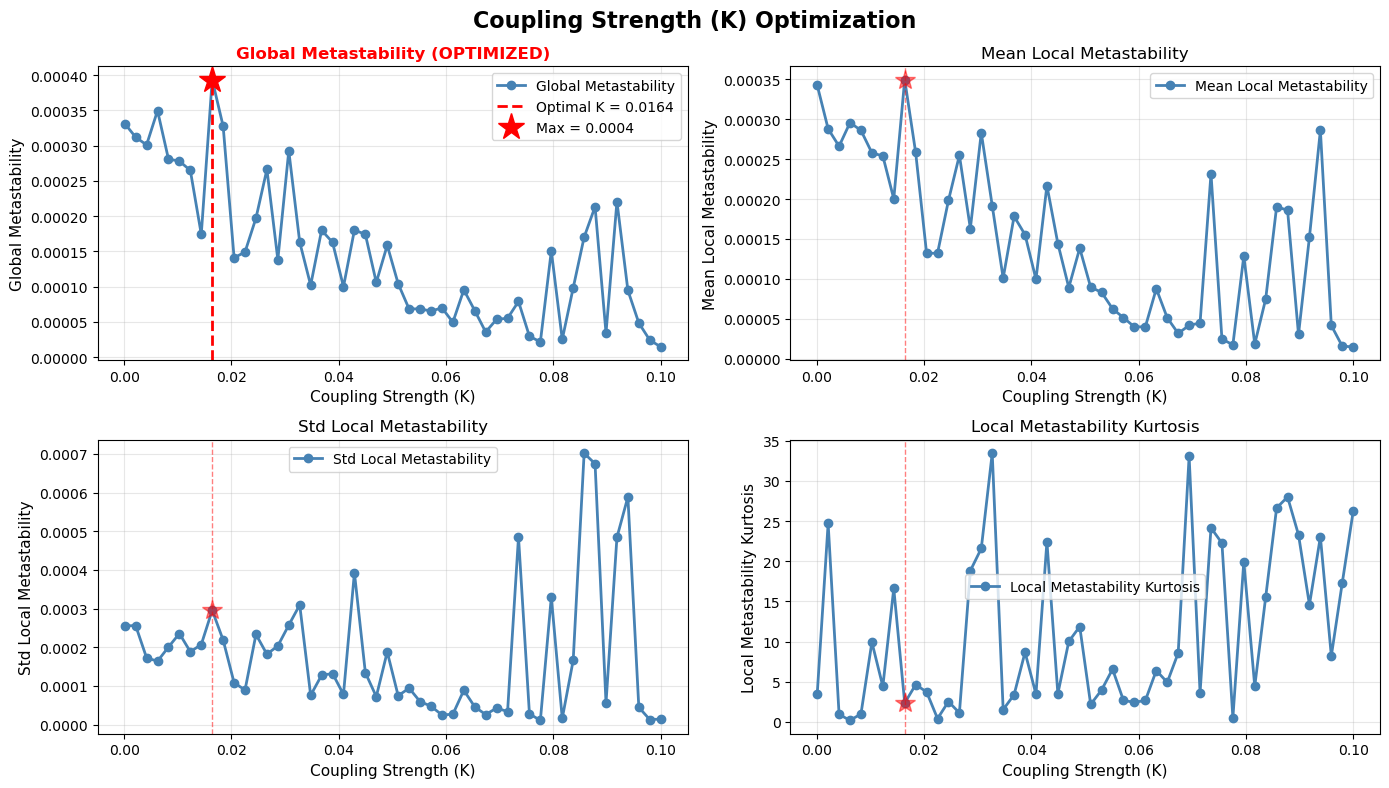


Tip: You can also optimize for different metrics:
  - 'global': maximize global synchronization variability
  - 'local_mean': maximize average local metastability
  - 'local_std': maximize heterogeneity of local dynamics
  - 'local_kurtosis': optimize for heavy-tailed local dynamics


In [10]:
# Create a random connectivity matrix
A = (A + A.T) / 2  # Make symmetric
np.fill_diagonal(A, 0)  # No self-connections
A = A / A.sum(axis=1, keepdims=True)  # Normalize

# Find optimal K
optimal_K, results = find_optimal_K(
    A, 
    K_range=np.linspace(0.0001, 0.1, 50),
    metric='global',
    sim_time=200,  # Shorter for example
    verbose=True
)

# Plot results
plot_K_optimization(results)

print("\nTip: You can also optimize for different metrics:")
print("  - 'global': maximize global synchronization variability")
print("  - 'local_mean': maximize average local metastability")
print("  - 'local_std': maximize heterogeneity of local dynamics")
print("  - 'local_kurtosis': optimize for heavy-tailed local dynamics")

In [14]:
save_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/optimize_K")

Optimizing K: 100%|██████████| 50/50 [04:52<00:00,  5.85s/it]



Optimization Results:
Metric optimized: global
Optimal K: 0.0001
Value at optimal K: 0.0000
K range tested: [0.0001, 0.1000]
Number of K values: 50



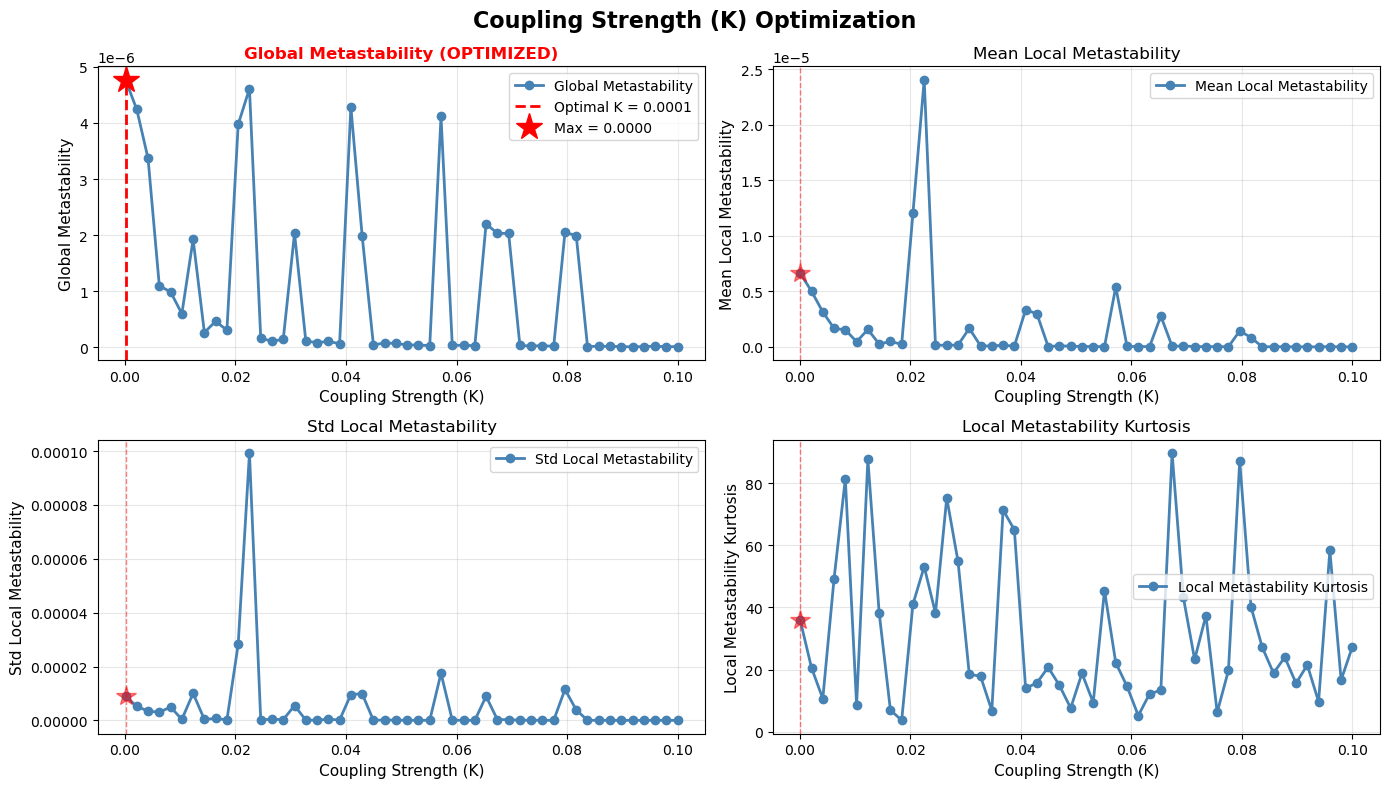

In [17]:
# bin and thres and sampled to 100 nodes total: 

all_results = {}

data_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy"

for animal_id in [0, 103, 169, 188, 206]:  # You can add more animal IDs here
    data_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/01_consensus_bin_density_10_percent_50.npy"
     # Load connectivity matrix
    A = np.load(data_path)[0]

    # Create a random connectivity matrix
    A = (A + A.T) / 2  # Make symmetric
    np.fill_diagonal(A, 0)  # No self-connections
    A = A / A.sum(axis=1, keepdims=True)  # Normalize

    # Find optimal K
    optimal_K, results = find_optimal_K(
        A, 
        K_range=np.linspace(0.0001, 0.1, 50),
        metric='global',
        sim_time=2000,  # Shorter for example
        verbose=True
    )

    # Plot results
    plot_K_optimization(results)
    plt.show()
    
    results = {"optimal_K": optimal_K, 
                "results": results}

    all_results.update({"data_id_{}".format(animal_id): results})

    # save intermediate results
    np.save(save_path / "optimize_K_results_partial.npy", all_results)
    
    break # 5 min, 15s 

In [6]:
optimal_K

np.float64(0.001)

In [7]:
results

{'K_values': array([0.001     , 0.00621053, 0.01142105, 0.01663158, 0.02184211,
        0.02705263, 0.03226316, 0.03747368, 0.04268421, 0.04789474,
        0.05310526, 0.05831579, 0.06352632, 0.06873684, 0.07394737,
        0.07915789, 0.08436842, 0.08957895, 0.09478947, 0.1       ]),
 'global': array([3.37111625e-04, 3.07640850e-04, 3.06690996e-04, 2.32844635e-04,
        2.92740130e-04, 2.18401212e-04, 1.60097271e-04, 1.30623828e-04,
        1.17574385e-04, 8.32936363e-05, 5.42828659e-05, 1.43507521e-04,
        6.90978652e-05, 4.95019534e-05, 3.52299443e-05, 5.11419101e-05,
        4.11413404e-05, 4.37912742e-05, 3.90594602e-05, 1.82554686e-05]),
 'local_mean': array([5.75714370e-04, 3.80522661e-04, 4.33360591e-04, 3.15549985e-04,
        3.77423313e-04, 3.43822541e-04, 2.33977243e-04, 1.61477366e-04,
        1.54842917e-04, 9.63952030e-05, 6.00463876e-05, 2.68921810e-04,
        8.29301499e-05, 5.69378572e-05, 4.49976018e-05, 4.86583116e-05,
        4.41014350e-05, 5.48987582e-05, 

In [ ]:
# bin and thres and sampled to 100 nodes total: 

all_results = {}
dataset_type = "01_consensus_bin_density_10_percent_50" # 01_connectomes_orig, bin_density_10_percent_50

for animal_id in [0, 103, 169, 188, 206]:  # You can add more animal IDs here
    data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{dataset_type}.npy"
     # Load connectivity matrix
    A = np.load(data_path)[0]

    # Create a random connectivity matrix
    A = (A + A.T) / 2  # Make symmetric
    np.fill_diagonal(A, 0)  # No self-connections
    A = A / A.sum(axis=1, keepdims=True)  # Normalize

    # Find optimal K
    optimal_K, results = find_optimal_K(
        A, 
        K_range=np.linspace(0.0001, 0.1, 50),
        metric='global',
        sim_time=2000,  # Shorter for example
        verbose=True
    )

    # Plot results
    plot_K_optimization(results)
    plt.show()
    
    results = {"optimal_K": optimal_K, 
                "results": results}

    all_results.update({"data_id_{}".format(animal_id): results})

    # save intermediate results
    np.save(save_path / "optimize_K_results_partial.npy", all_results)
    
    break # 5 min, 15s 

Optimizing K: 100%|██████████| 50/50 [18:27<00:00, 22.16s/it]



Optimization Results:
Metric optimized: global
Optimal K: 0.0001
Value at optimal K: 0.0000
K range tested: [0.0001, 0.1000]
Number of K values: 50



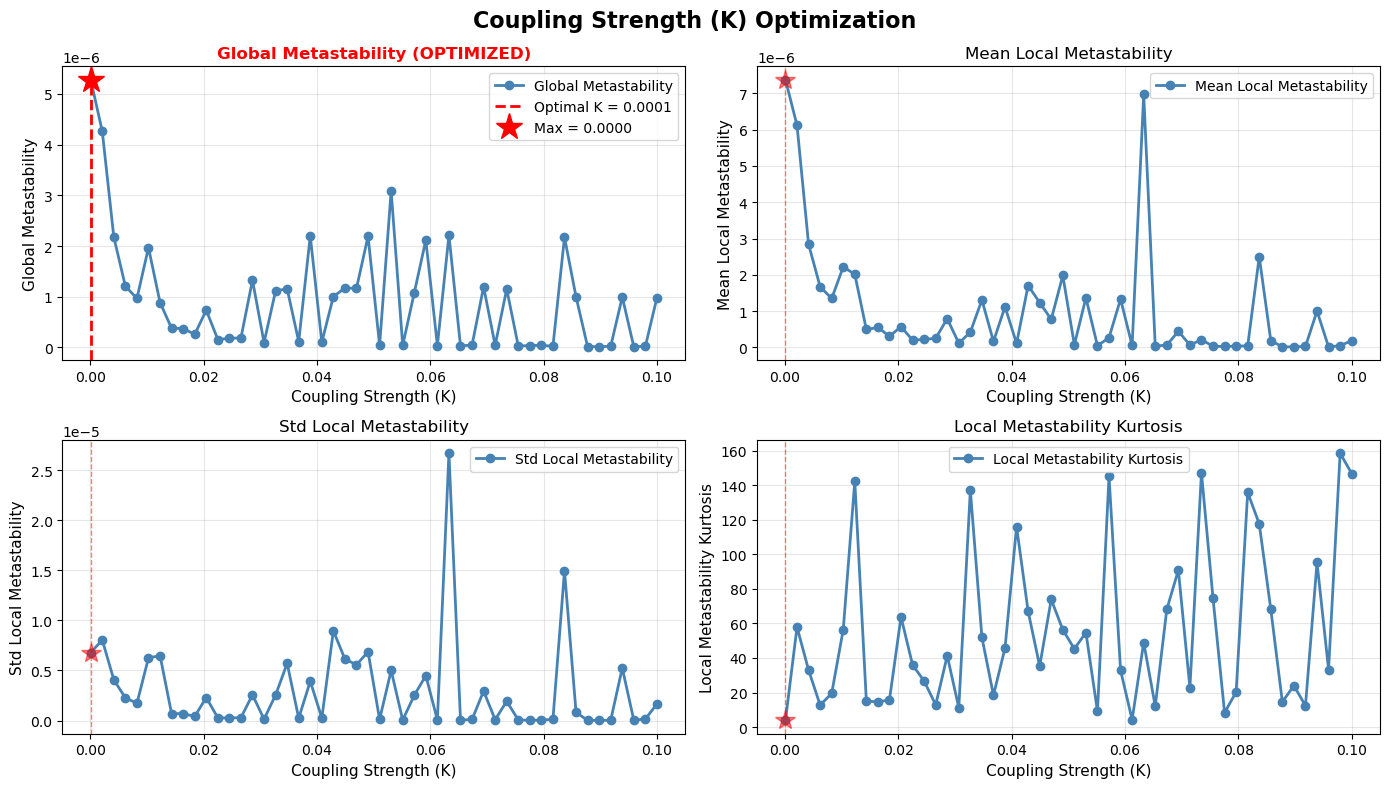

In [19]:
# bin and thres and sampled to 100 nodes total: 

all_results = {}
dataset_type = "00_connectomes_orig" # 01_consensus_bin_density_10_percent_50" # 00_connectomes_orig, bin_density_10_percent_50

for animal_id in [0, 103, 169, 188, 206]:  # You can add more animal IDs here
    data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{dataset_type}.npy"
     # Load connectivity matrix
    A = np.load(data_path)[0]

    # Create a random connectivity matrix
    A = (A + A.T) / 2  # Make symmetric
    np.fill_diagonal(A, 0)  # No self-connections
    A = A / A.sum(axis=1, keepdims=True)  # Normalize

    # Find optimal K
    optimal_K, results = find_optimal_K(
        A, 
        K_range=np.linspace(0.0001, 0.1, 50),
        metric='global',
        sim_time=2000,  # Shorter for example
        verbose=True
    )

    # Plot results
    plot_K_optimization(results)
    plt.show()
    
    results = {"optimal_K": optimal_K, 
                "results": results}

    all_results.update({"data_id_{}".format(animal_id): results})

    # save intermediate results
    np.save(save_path / "optimize_K_results_partial.npy", all_results)
    
    break # 